# Track A — XGBoost Comparison

本 Notebook 讀取 `src/train_xgboost.py` 已產生的可重現結果，檢查 XGBoost 是否在相同 top-100 站點、feature schema 與時間切分下優於現有 HGB。Target 仍是 hourly transfer-related borrowing demand，不是即時 availability 或缺車風險。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

project_root = Path.cwd()
if not (project_root / 'results').exists():
    project_root = project_root.parent
results_dir = project_root / 'results'
assert results_dir.exists(), 'Could not locate the repository results directory.'

## Holdout model comparison

In [2]:
comparison = pd.read_csv(results_dir / 'model_comparison_metrics.csv')
test_metrics = comparison.loc[comparison['split'].eq('test'), ['model', 'mae', 'rmse', 'r2']].copy()
test_metrics.sort_values('mae').round(3)

,model,mae,rmse,r2
11,hist_gradient_boosting_weather,1.575,2.549,0.794
13,xgboost_weather,1.597,2.580,0.789
9,hist_gradient_boosting,1.601,2.567,0.791
7,ridge_time_history_weather,1.793,2.889,0.736
5,ridge_time_history,1.810,2.911,0.731
3,seasonal_168h,2.176,3.701,0.566
2,persistence_1h,2.441,4.129,0.460


In [3]:
metric_index = test_metrics.set_index('model')
hgb_mae = metric_index.loc['hist_gradient_boosting_weather', 'mae']
xgb_mae = metric_index.loc['xgboost_weather', 'mae']
ridge_mae = metric_index.loc['ridge_time_history_weather', 'mae']
pd.Series({
    'XGBoost MAE relative to HGB (%)': (xgb_mae / hgb_mae - 1) * 100,
    'XGBoost MAE improvement over Ridge (%)': (1 - xgb_mae / ridge_mae) * 100,
}).round(2)

XGBoost MAE relative to HGB (%)            1.43
XGBoost MAE improvement over Ridge (%)    10.93
dtype: float64

## Validation-only tuning and rolling-origin stability

In [4]:
tuning = pd.read_csv(results_dir / 'xgboost_tuning.csv')
rolling = pd.read_csv(results_dir / 'xgboost_rolling_origin_metrics.csv')
display(tuning[['candidate', 'n_estimators', 'learning_rate', 'max_depth', 'mae', 'rmse', 'r2']].round(3))
rolling[['fold', 'validation_start', 'validation_end', 'mae', 'rmse', 'r2']].round(3)

,candidate,n_estimators,learning_rate,max_depth,mae,rmse,r2
0,compact,300,0.05,6,1.665,2.716,0.782
1,regularized,500,0.03,8,1.646,2.687,0.786


,fold,validation_start,validation_end,mae,rmse,r2
0,fold_1,2023-10-01T00:00:00+08:00,2023-10-20T23:00:00+08:00,1.673,2.787,0.750
1,fold_2,2023-10-21T00:00:00+08:00,2023-11-10T23:00:00+08:00,1.624,2.609,0.813
2,fold_3,2023-11-11T00:00:00+08:00,2023-11-30T23:00:00+08:00,1.644,2.663,0.789


## Permutation importance

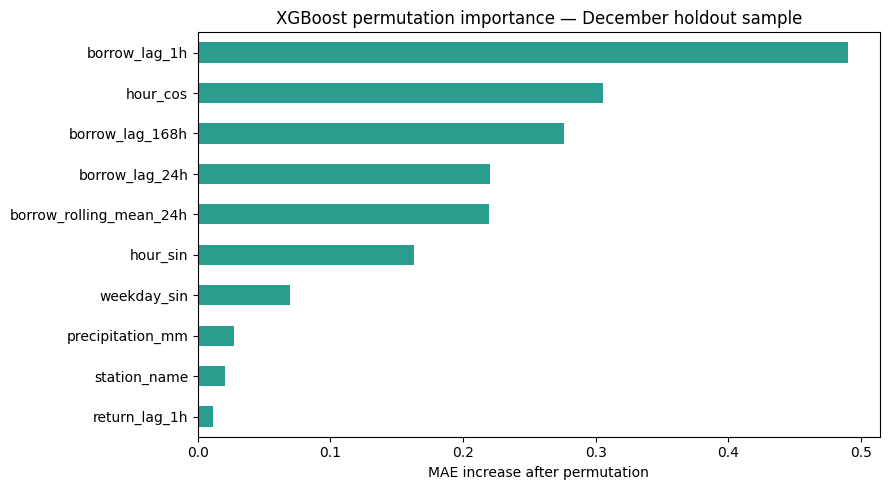

In [5]:
importance = pd.read_csv(results_dir / 'xgboost_permutation_importance.csv').head(10).sort_values('mae_increase_mean')
ax = importance.plot.barh(x='feature', y='mae_increase_mean', legend=False, color='#2A9D8F', figsize=(9, 5))
ax.set_xlabel('MAE increase after permutation')
ax.set_ylabel('')
ax.set_title('XGBoost permutation importance — December holdout sample')
plt.tight_layout()
plt.show()

## Largest individual errors

In [6]:
worst = pd.read_csv(results_dir / 'xgboost_worst_cases.csv')
worst[['event_time', 'station_name', 'borrow_count', 'prediction', 'signed_error', 'absolute_error']].head(10).round(2)

,event_time,station_name,borrow_count,prediction,signed_error,absolute_error
0,2023-12-22 08:00:00+08:00,捷運公館站(2號出口),77.0,44.26,32.74,32.74
1,2023-12-05 18:00:00+08:00,捷運劍潭站(2號出口),70.0,37.39,32.61,32.61
2,2023-12-21 08:00:00+08:00,捷運公館站(3號出口),51.0,20.65,30.35,30.35
3,2023-12-11 18:00:00+08:00,捷運劍潭站(2號出口),65.0,35.08,29.92,29.92
4,2023-12-13 19:00:00+08:00,捷運劍潭站(2號出口),6.0,35.87,-29.87,29.87
5,2023-12-25 08:00:00+08:00,捷運中山國中站,49.0,21.55,27.45,27.45
6,2023-12-21 08:00:00+08:00,捷運公館站(2號出口),58.0,31.52,26.48,26.48
7,2023-12-03 08:00:00+08:00,捷運公館站(2號出口),47.0,20.52,26.48,26.48
8,2023-12-29 08:00:00+08:00,捷運公館站(2號出口),24.0,50.19,-26.19,26.19
9,2023-12-11 08:00:00+08:00,捷運中山國中站,46.0,20.94,25.06,25.06


## Conclusion

- Validation 選出 `regularized` candidate，test 未參與調參。
- XGBoost 的 December holdout MAE 為 1.597，優於含天氣 Ridge，但略高於 HGB 的 1.575。
- 三段 rolling-origin MAE 介於 1.624–1.673，也略高於現有 HGB folds。
- 因此不以模型名稱決定主模型；HGB 仍保留為 Track A 的主要模型。
- Worst cases 顯示尖峰高需求仍可能明顯低估或高估，但不能在沒有事件資料時推測原因。